[[17.  4.]
 [ 4.  5.]]


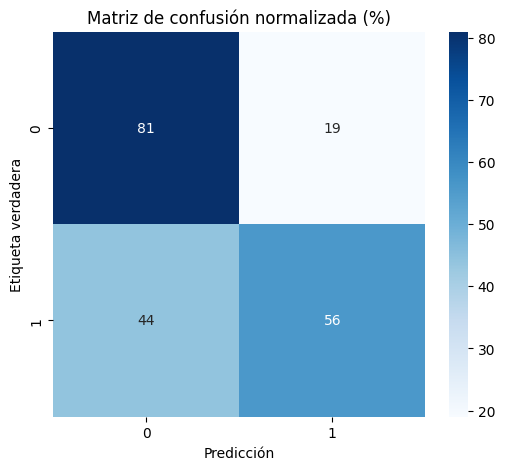

Accuracy: 0.7333333333333333

Reporte por clase:
               precision    recall  f1-score   support

           0     0.8095    0.8095    0.8095        21
           1     0.5556    0.5556    0.5556         9

    accuracy                         0.7333        30
   macro avg     0.6825    0.6825    0.6825        30
weighted avg     0.7333    0.7333    0.7333        30



In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score

# ==============================
# 🔹 1. Matriz de confusión fija
# Matrix definitions
def normalize_confusion_matrix(cm):
    """
    Normaliza la matriz de confusión a porcentajes enteros por fila.
    Devuelve una matriz donde cada fila suma 100 (aprox, por redondeo).
    """
    cm = np.asarray(cm, dtype=float)
    row_sums = cm.sum(axis=1, keepdims=True)
    norm_cm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums!=0) * 100
    norm_cm = np.round(norm_cm).astype(int)
    print(cm)
    return norm_cm
cm = np.array([
    [17, 4],
    [4, 5]
])

cm_norm = normalize_confusion_matrix(cm)

# ==============================
# 🔹 2. Dibujar matriz
# ==============================
labels = [0, 1]
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta verdadera")
plt.title("Matriz de confusión normalizada (%)")
plt.show()

# ==============================
# 🔹 3. Calcular métricas básicas
# ==============================
# Reconstruimos y_true / y_pred a partir de la matriz original (no normalizada)
y_true, y_pred = [], []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        y_true.extend([i]*int(cm[i,j]))
        y_pred.extend([j]*int(cm[i,j]))

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nReporte por clase:\n", classification_report(y_true, y_pred, labels=labels, zero_division=0, digits=4))


![image.png](attachment:image.png)